# Non-Convex Loss Landscape Example

This notebook demonstrates a non-convex optimization landscape with local minima, which is common in statistical models like neural networks or mixture models. We'll visualize both the loss function and its gradient to show how optimization algorithms can get trapped in local minima.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.optimize import minimize
from pathlib import Path

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


from bettercode.utils import save_fig

IMAGE_DIR = Path('../../latex/figures')
CHAPTER = 9


## Define a Non-Convex Loss Function

We'll create a loss function that combines multiple Gaussian-like components to create a landscape with multiple local minima. This is similar to what you might encounter in mixture models or neural network training.

In [2]:
def non_convex_loss(params):
    """
    A rough, non-convex loss function with multiple local minima.
    This function combines multiple Gaussian-like components with
    significant oscillatory noise to create a very challenging
    optimization landscape with many small local minima.
    
    Args:
        params: array-like, [x, y] coordinates
    
    Returns:
        float: loss value
    """
    x, y = params
    
    # Multiple Gaussian components with different centers and scales
    loss = (
        # Main valley with global minimum
        0.5 * (x**2 + y**2) +
        
        # Local minimum 1
        2.0 * np.exp(-((x - 2)**2 + (y - 1)**2) / 0.5) +
        
        # Local minimum 2
        1.5 * np.exp(-((x + 1.5)**2 + (y + 1)**2) / 0.3) +
        
        # Local minimum 3
        1.8 * np.exp(-((x - 0.5)**2 + (y + 2)**2) / 0.4) +
        
        # Moderate oscillatory noise components
        0.5 * np.sin(6 * x) * np.cos(4 * y) +
        0.4 * np.sin(8 * y) * np.cos(7 * x) +
        0.3 * np.sin(10 * x + 5 * y) * np.cos(6 * x - 3 * y) +
        
        # Medium-frequency roughness (reduced intensity)
        0.2 * np.sin(12 * x) * np.sin(10 * y) +
        0.15 * np.cos(15 * x) * np.cos(13 * y) +
        
        # Localized irregular features (gentler)
        0.3 * np.exp(-((x - 1)**2 + (y - 0.5)**2) / 0.2) * np.sin(18 * x) +
        0.25 * np.exp(-((x + 0.8)**2 + (y + 1.2)**2) / 0.15) * np.cos(20 * y) +
        
        # Reduced cross-frequency modulation
        0.15 * np.sin(5 * x) * np.sin(3 * y) * np.cos(8 * x * y) +
        0.1 * np.cos(6 * x + 2 * y) * np.sin(9 * x - 4 * y)
    )
    
    return loss

def gradient_non_convex_loss(params):
    """
    Analytical gradient of the rough non-convex loss function.
    Note: This is a simplified approximation - the full analytical gradient
    would be very complex due to all the oscillatory terms.
    """
    x, y = params
    
    # Main partial derivatives (simplified for the main components)
    dx = (
        x +  # from 0.5 * x^2
        -2.0 * 2 * (x - 2) / 0.5 * np.exp(-((x - 2)**2 + (y - 1)**2) / 0.5) +
        -1.5 * 2 * (x + 1.5) / 0.3 * np.exp(-((x + 1.5)**2 + (y + 1)**2) / 0.3) +
        -1.8 * 2 * (x - 0.5) / 0.4 * np.exp(-((x - 0.5)**2 + (y + 2)**2) / 0.4) +
        # Simplified oscillatory derivatives (major terms only)
        0.5 * 6 * np.cos(6 * x) * np.cos(4 * y) +
        0.4 * (-7) * np.sin(8 * y) * np.sin(7 * x) +
        0.3 * 10 * np.cos(10 * x + 5 * y) * np.cos(6 * x - 3 * y) +
        0.3 * 6 * np.sin(10 * x + 5 * y) * (-np.sin(6 * x - 3 * y)) +
        0.2 * 12 * np.cos(12 * x) * np.sin(10 * y) +
        0.15 * (-15) * np.sin(15 * x) * np.cos(13 * y)
    )
    
    dy = (
        y +  # from 0.5 * y^2
        -2.0 * 2 * (y - 1) / 0.5 * np.exp(-((x - 2)**2 + (y - 1)**2) / 0.5) +
        -1.5 * 2 * (y + 1) / 0.3 * np.exp(-((x + 1.5)**2 + (y + 1)**2) / 0.3) +
        -1.8 * 2 * (y + 2) / 0.4 * np.exp(-((x - 0.5)**2 + (y + 2)**2) / 0.4) +
        # Simplified oscillatory derivatives (major terms only)
        0.5 * np.sin(6 * x) * (-4) * np.sin(4 * y) +
        0.4 * 8 * np.cos(8 * y) * np.cos(7 * x) +
        0.3 * 5 * np.cos(10 * x + 5 * y) * np.cos(6 * x - 3 * y) +
        0.3 * (-3) * np.sin(10 * x + 5 * y) * (-np.sin(6 * x - 3 * y)) +
        0.2 * np.sin(12 * x) * 10 * np.cos(10 * y) +
        0.15 * np.cos(15 * x) * (-13) * np.sin(13 * y)
    )
    
    return np.array([dx, dy])

## 3D Visualization of the Loss Landscape

Let's create a 3D surface plot to visualize the non-convex loss landscape with its multiple local minima.

Found global minimum at: (-0.176, 0.025) with loss: -0.7470


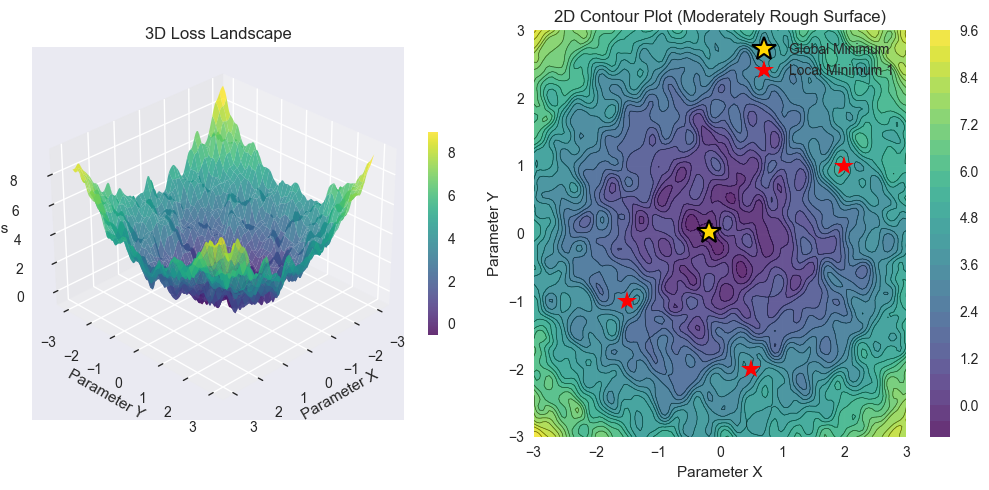

Moderately rough loss landscape created!
Gold star marks the true global minimum at (-0.176, 0.025)
Red stars show local minima in other regions.
The surface has interesting complexity without excessive oscillations.


In [3]:
# Create a grid of points to evaluate the loss function
x_range = np.linspace(-3, 3, 120)  # Slightly reduced resolution
y_range = np.linspace(-3, 3, 120)
X, Y = np.meshgrid(x_range, y_range)

# Evaluate the loss function over the grid
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = non_convex_loss([X[i, j], Y[i, j]])

# Create the 3D surface plot
fig = plt.figure(figsize=(15, 5))

# 3D surface plot
ax1 = fig.add_subplot(131, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True)
ax1.set_xlabel('Parameter X')
ax1.set_ylabel('Parameter Y')
ax1.set_zlabel('Loss')
ax1.set_title('3D Loss Landscape')
ax1.view_init(elev=30, azim=45)

# Add colorbar
fig.colorbar(surf, ax=ax1, shrink=0.5)

# 2D contour plot
ax2 = fig.add_subplot(132)
contour = ax2.contour(X, Y, Z, levels=30, colors='black', alpha=0.6, linewidths=0.5)
contourf = ax2.contourf(X, Y, Z, levels=30, cmap='viridis', alpha=0.8)
ax2.set_xlabel('Parameter X')
ax2.set_ylabel('Parameter Y')
ax2.set_title('2D Contour Plot (Moderately Rough Surface)')
ax2.grid(True, alpha=0.3)
fig.colorbar(contourf, ax=ax2)

# Find the actual global minimum from the grid
min_idx = np.unravel_index(np.argmin(Z), Z.shape)
global_min_x = X[min_idx]
global_min_y = Y[min_idx]
global_min_loss = Z[min_idx]

print(f"Found global minimum at: ({global_min_x:.3f}, {global_min_y:.3f}) with loss: {global_min_loss:.4f}")

# Mark local minima (approximate locations)
local_minima = [
    [global_min_x, global_min_y],  # True global minimum from grid search
    [2, 1],      # Local minimum 1
    [-1.5, -1],  # Local minimum 2
    [0.5, -2]    # Local minimum 3
]

for i, (x_min, y_min) in enumerate(local_minima):
    if i == 0:  # Global minimum
        ax2.plot(x_min, y_min, '*', color='gold', markersize=18, 
                 markeredgecolor='black', markeredgewidth=1.5,
                 label='Global Minimum', zorder=10)
    else:  # Local minima
        ax2.plot(x_min, y_min, 'r*', markersize=15, 
                 label=f'Local Minimum {i}' if i == 1 else '')

ax2.legend()

plt.tight_layout()
plt.show()

print("Moderately rough loss landscape created!")
print(f"Gold star marks the true global minimum at ({global_min_x:.3f}, {global_min_y:.3f})")
print("Red stars show local minima in other regions.")
print("The surface has interesting complexity without excessive oscillations.")

## Gradient Visualization

Now let's visualize the gradient field to show how the optimization would flow across the landscape. The arrows show the direction of steepest descent, and their length indicates the magnitude of the gradient.

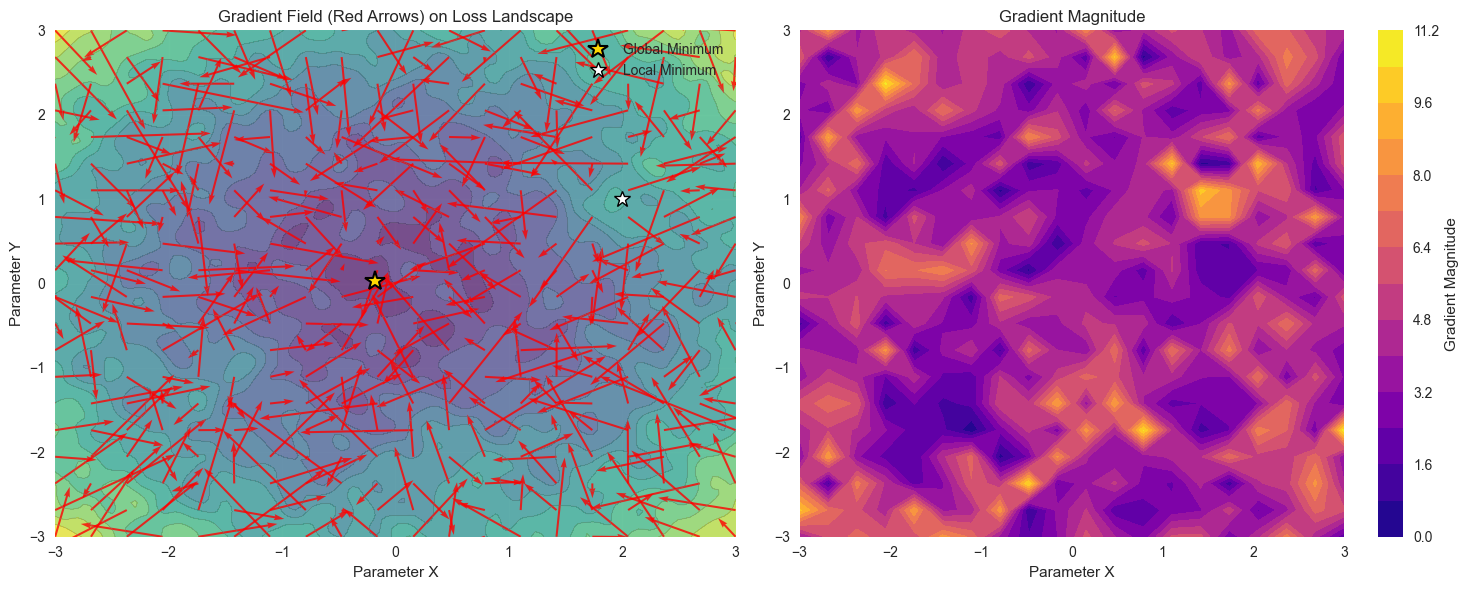

Gradient visualization complete!
- Red arrows show the direction of steepest descent
- Longer arrows indicate larger gradient magnitudes
- Red dots in the second plot show areas with near-zero gradients (critical points)


In [4]:
# Create a coarser grid for gradient visualization (for better visibility)
x_grad = np.linspace(-3, 3, 20)
y_grad = np.linspace(-3, 3, 20)
X_grad, Y_grad = np.meshgrid(x_grad, y_grad)

# Calculate gradients
U = np.zeros_like(X_grad)
V = np.zeros_like(Y_grad)

for i in range(X_grad.shape[0]):
    for j in range(X_grad.shape[1]):
        grad = gradient_non_convex_loss([X_grad[i, j], Y_grad[i, j]])
        U[i, j] = -grad[0]  # Negative for descent direction
        V[i, j] = -grad[1]  # Negative for descent direction

# Create gradient visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Contour with gradient field
contour = ax1.contour(X, Y, Z, levels=15, colors='gray', alpha=0.6, linewidths=0.5)
contourf = ax1.contourf(X, Y, Z, levels=15, cmap='viridis', alpha=0.7)
ax1.quiver(X_grad, Y_grad, U, V, alpha=0.8, color='red', scale=50, width=0.003)
ax1.set_xlabel('Parameter X')
ax1.set_ylabel('Parameter Y')
ax1.set_title('Gradient Field (Red Arrows) on Loss Landscape')
ax1.grid(True, alpha=0.3)

# Mark local minima
for i, (x_min, y_min) in enumerate(local_minima):
    if i == 0:  # Global minimum
        ax1.plot(x_min, y_min, '*', color='gold', markersize=15, 
                 markeredgecolor='black', markeredgewidth=1.5,
                 label='Global Minimum', zorder=10)
    elif i == 1:  # Show only first local minimum for clarity
        ax1.plot(x_min, y_min, 'w*', markersize=12, markeredgecolor='black', markeredgewidth=1,
                 label='Local Minimum')

ax1.legend()

# Plot 2: Gradient magnitude
grad_magnitude = np.sqrt(U**2 + V**2)
contour_mag = ax2.contourf(X_grad, Y_grad, grad_magnitude, levels=15, cmap='plasma')
ax2.set_xlabel('Parameter X')
ax2.set_ylabel('Parameter Y')
ax2.set_title('Gradient Magnitude')
fig.colorbar(contour_mag, ax=ax2, label='Gradient Magnitude')

# Mark points where gradient is near zero (minima/maxima)
zero_grad_threshold = 0.1
for i in range(X_grad.shape[0]):
    for j in range(X_grad.shape[1]):
        if grad_magnitude[i, j] < zero_grad_threshold:
            ax2.plot(X_grad[i, j], Y_grad[i, j], 'ro', markersize=8)

plt.tight_layout()
plt.show()

print("Gradient visualization complete!")
print("- Red arrows show the direction of steepest descent")
print("- Longer arrows indicate larger gradient magnitudes")
print("- Red dots in the second plot show areas with near-zero gradients (critical points)")

## Optimization Trajectories

Let's demonstrate how different starting points lead to different local minima by running gradient descent from various initial positions.

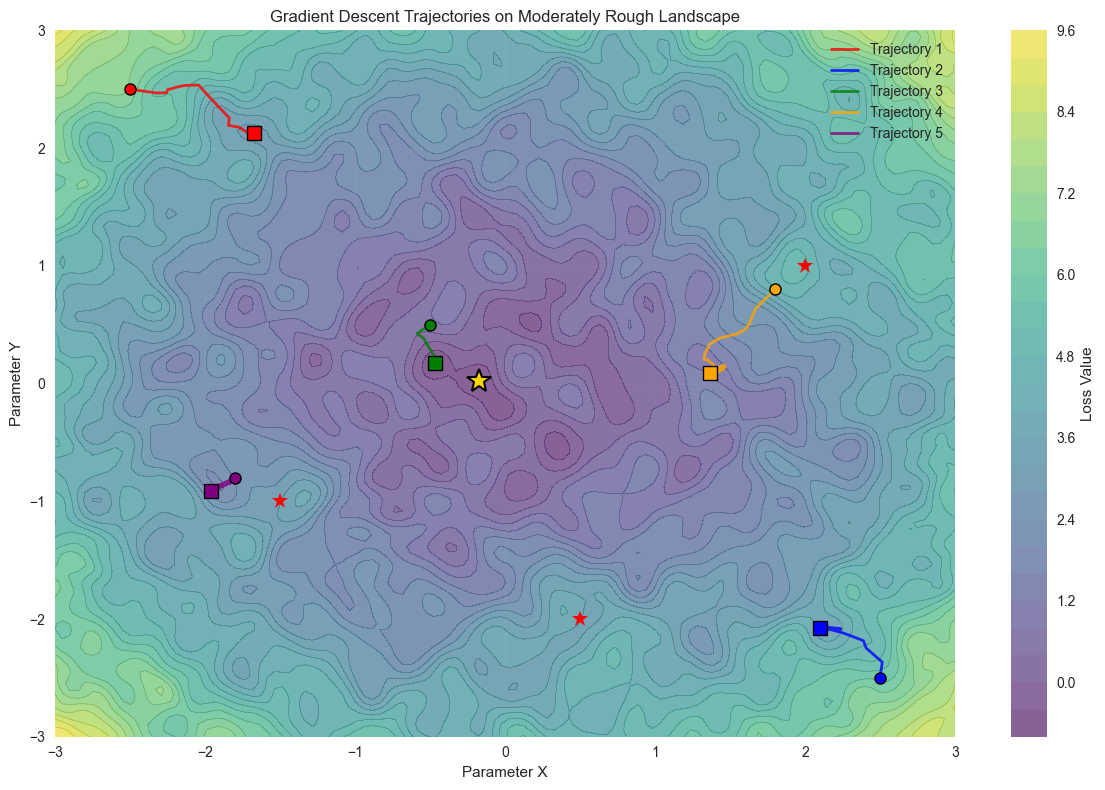

Optimization Results:
Trajectory 1:
  Starting point: [-2.50, 2.50]
  Final point:    [-1.67, 2.13]
  Final loss:     3.0452
  Iterations:     193

Trajectory 2:
  Starting point: [2.50, -2.50]
  Final point:    [2.10, -2.08]
  Final loss:     3.8243
  Iterations:     1001

Trajectory 3:
  Starting point: [-0.50, 0.50]
  Final point:    [-0.47, 0.18]
  Final loss:     -0.6409
  Iterations:     37

Trajectory 4:
  Starting point: [1.80, 0.80]
  Final point:    [1.36, 0.09]
  Final loss:     1.1689
  Iterations:     1001

Trajectory 5:
  Starting point: [-1.80, -0.80]
  Final point:    [-1.96, -0.91]
  Final loss:     2.2146
  Iterations:     1001



In [5]:
# Define gradient descent function
def gradient_descent(start_point, learning_rate=0.1, max_iterations=1000, tolerance=1e-6):
    """Simple gradient descent implementation."""
    path = [start_point.copy()]
    current = start_point.copy()
    
    for i in range(max_iterations):
        grad = gradient_non_convex_loss(current)
        
        # Check if we've converged
        if np.linalg.norm(grad) < tolerance:
            break
            
        # Update parameters
        current = current - learning_rate * grad
        path.append(current.copy())
    
    return np.array(path)

# Test different starting points
starting_points = [
    np.array([-2.5, 2.5]),   # Should converge to local minimum
    np.array([2.5, -2.5]),   # Should converge to different local minimum
    np.array([-0.5, 0.5]),   # Should converge to global minimum
    np.array([1.8, 0.8]),    # Near local minimum 1
    np.array([-1.8, -0.8]),  # Near local minimum 2
]

# Run optimization from each starting point
trajectories = []
final_points = []
final_losses = []

for start in starting_points:
    path = gradient_descent(start, learning_rate=0.03)  # Slightly increased learning rate
    trajectories.append(path)
    final_points.append(path[-1])
    final_losses.append(non_convex_loss(path[-1]))

# Visualize the optimization trajectories
fig, ax = plt.subplots(figsize=(12, 8))

# Plot contour map
contour = ax.contour(X, Y, Z, levels=25, colors='gray', alpha=0.4, linewidths=0.5)
contourf = ax.contourf(X, Y, Z, levels=25, cmap='viridis', alpha=0.6)

# Plot trajectories
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i, (traj, color) in enumerate(zip(trajectories, colors)):
    ax.plot(traj[:, 0], traj[:, 1], color=color, linewidth=2, alpha=0.8, 
            label=f'Trajectory {i+1}')
    # Mark starting point
    ax.plot(traj[0, 0], traj[0, 1], 'o', color=color, markersize=8, 
            markeredgecolor='black', markeredgewidth=1)
    # Mark ending point
    ax.plot(traj[-1, 0], traj[-1, 1], 's', color=color, markersize=10, 
            markeredgecolor='black', markeredgewidth=1)

ax.set_xlabel('Parameter X')
ax.set_ylabel('Parameter Y')
ax.set_title('Gradient Descent Trajectories on Moderately Rough Landscape')
ax.legend()
ax.grid(True, alpha=0.3)

# Mark the minima on the trajectory plot
for i, (x_min, y_min) in enumerate(local_minima):
    if i == 0:  # Global minimum
        ax.plot(x_min, y_min, '*', color='gold', markersize=18, 
                markeredgecolor='black', markeredgewidth=1.5,
                label='Global Minimum', zorder=10)
    else:  # Local minima
        ax.plot(x_min, y_min, 'r*', markersize=12, 
                label='Local Minima' if i == 1 else '', zorder=9)

# Add colorbar
fig.colorbar(contourf, ax=ax, label='Loss Value')

plt.tight_layout()
save_fig(fig, 'ComplexLoss', CHAPTER, basedir=IMAGE_DIR)

# plt.savefig(FIGURE_DIR / "optimization_trajectories_moderately_rough.png", dpi=300)
plt.show()

# Print results
print("Optimization Results:")
print("=" * 50)
for i, (start, final, loss) in enumerate(zip(starting_points, final_points, final_losses)):
    print(f"Trajectory {i+1}:")
    print(f"  Starting point: [{start[0]:.2f}, {start[1]:.2f}]")
    print(f"  Final point:    [{final[0]:.2f}, {final[1]:.2f}]")
    print(f"  Final loss:     {loss:.4f}")
    print(f"  Iterations:     {len(trajectories[i])}")
    print()

## Summary

This example demonstrates key concepts in rough, non-convex optimization:

1. **Many Local Minima**: The rough landscape has numerous small local minima where gradient descent can get trapped
2. **High-Frequency Oscillations**: Small-scale variations make optimization very challenging
3. **Sensitivity to Learning Rate**: Rough surfaces require careful tuning of optimization parameters
4. **Multiple Scales**: The landscape has both large-scale structure (major valleys) and small-scale roughness

### Real-world Applications

This type of rough, non-convex landscape is common in:
- **Deep Neural Networks**: Loss surfaces with many local minima and saddle points
- **Hyperparameter Optimization**: Noisy objective functions from cross-validation
- **Reinforcement Learning**: Policy optimization in complex environments
- **Scientific Computing**: Fitting complex models to noisy experimental data

### Optimization Strategies

To deal with rough, non-convex landscapes:
- **Adaptive Learning Rates**: Use methods like Adam or RMSprop that adapt to local gradient behavior
- **Multiple Random Restarts**: Run optimization many times from different initial points
- **Ensemble Methods**: Combine results from multiple optimization runs
- **Advanced Optimizers**: Use second-order methods or evolutionary algorithms
- **Gradient Clipping**: Prevent large gradient steps in rough regions
- **Noise Injection**: Add noise to help escape shallow local minima